In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os,sys
cwd = os.getcwd()
sys.path.append(os.path.join(cwd,'../python'))
import threepoint

## Using the data class to output the measurement results to a fits file

In [12]:
# Initialize the 3pt data class
# The first argument is the name of the data
# The second is the bin_type, SSS stands for side-side-side 
#   (since map3 is parametrized by the 3 aperture radii, this can be interpreted as 
#   the 3 sides of a triangle effectively although three sides must not form triangle.)
thpt = threepoint.ThreePointDataClass('map3', 'SSS')

In [13]:
# Example:
################################ Preparing data as array ################################
# Redshift combinations
z = np.array([[1,1,1],[1,1,2],[1,1,3],[1,1,4],[1,2,2],[1,2,3],[1,2,4],[1,3,3],[1,3,4],[1,4,4],[2,2,2],[2,2,3],[2,2,4],[2,3,3],[2,3,4],[2,4,4],[3,3,3],[3,3,4],[3,4,4],[4,4,4]])
z1, z2, z3 = z.T
nz = z1.size

# Aperture radii
t = np.array([7.0, 14.0, 25.0, 50.0])
t1 = t2 = t3 = t # same radii for map3 in our simplest setup
nt = t.size

## duplicate the zbin `nt` times because each zbin combination has `nt` data vector
z1 = np.repeat(z1, nt)
z2 = np.repeat(z2, nt)
z3 = np.repeat(z3, nt)

## Duplicate the tbin `nz` times, assuming the same aperture radii for all zbin combinations
t1 = np.tile(t1, nz)
t2 = np.tile(t2, nz)
t3 = np.tile(t3, nz)

# random signal
s = np.linspace(0, 1, nt*nz)

# random covariance
c = np.eye(nt*nz)
nsim = 400 # number of sims

################################ Putting data to the data class ################################
thpt.set_value(z1, z2, z3, t1, t2, t3, s)
thpt.set_covariance(c, nsim)

################################ Save the data ################################
# thpt.to_fits('test.fits')

################################ Load the data ################################
# thpt = threepoint.ThreePointDataClass.from_fits('test.fits')

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x1123c6190>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x11223c8d0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x112467c50>]

## Using selection methods
Selection array can be obtained using the selection methods. Assume that `sel` to be the selection array obtained from some method. Then, you can choose the zbin, trignale bin, signal as follows:
```
z1, z2, z3 = thpt.get_z_bin(sel)
b1, b2, b3 = thpt.get_t_bin(sel)
s = thpt.get_signal(sel)
c = thpt.get_covariance(sel)
ic= thpt.get_inverse_covariance(sel)
```

In [14]:
thpt = threepoint.ThreePointDataClass.from_fits('test.fits')

In [16]:
# Redshift bin selection
# Example 1: select elements with z1==1
sel = thpt.selection_z_bin(1, 'z1', '==')
print(sum(sel))
# Example 2: select elements with z1>1
sel = thpt.selection_z_bin(1, 'z1', '>')
print(sum(sel))
# Example 3: select elements with z1==1 and z2==1 and z2==1
sel = thpt.selection_z_bin(1, 'z', '==')
print(sum(sel))
# Example 4: select elements with z1>1 and z2>1 and z2>1
sel = thpt.selection_z_bin(1, 'z', '>')
print(sum(sel))
# Example 5: select elements with z1==1 and z2==2 and z3==3
sel = thpt.selection_z_bin([1,2,3], ['z1', 'z2', 'z3'], '==')
print(sum(sel))

40
40
40
40
4


In [17]:
# Triangle bin selection for SSS bin_type
# Example 1: select elements with t1==7.0
sel = thpt.selection_SSS_bin(7.0, 'theta1', '==')
print(sum(sel))
# Example 2: select elements with t1>7.0
sel = thpt.selection_SSS_bin(7.0, 'theta1', '>')
print(sum(sel))
# Example 3: select elements with t1==7.0 and t2==7.0 and t3==7.0
sel = thpt.selection_SSS_bin(7.0, 'theta', '==')
print(sum(sel))
# Example 4: select elements with t1>7.0 and t2>7.0 and t3>7.0
sel = thpt.selection_SSS_bin(7.0, 'theta', '>')
print(sum(sel))
# Example 5: select elements with t1==7.0 and t2==14.0 and t3==25.0
sel = thpt.selection_SSS_bin([7.0,14.0,25.0], ['theta1', 'theta2', 'theta3'], '==')
print(sum(sel))

20
60
20
60
0


## Ordering the entries nicely
If you are lazy and make the order of entries messy, then you can sort the entries using the `sort` method.

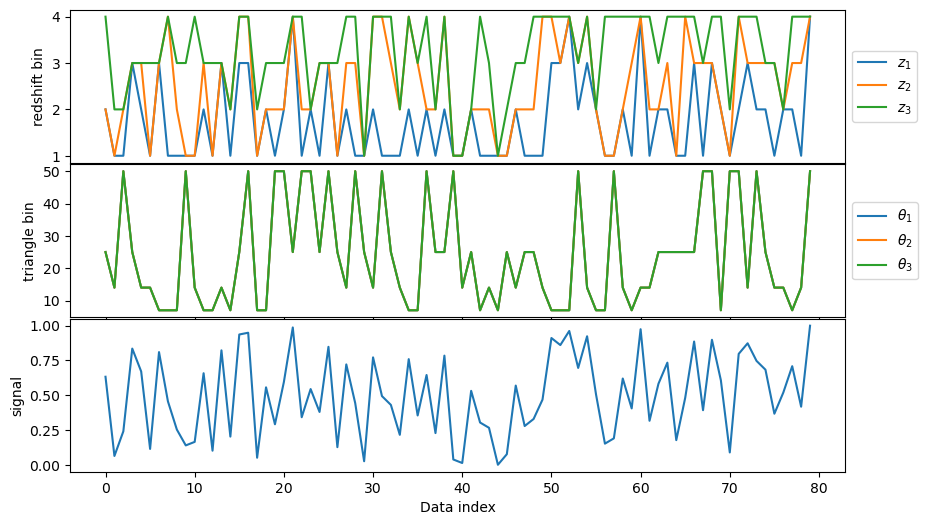

In [18]:
# shuffle the order of data
rng = np.random.default_rng(0)
o = rng.permutation(thpt.size)
thpt.replace(o)

# Data ordering before sort
fig, axes = plt.subplots(3,1, figsize=(10, 6), sharex=True)
plt.subplots_adjust(hspace=0.01)
z1, z2, z3 = thpt.get_z_bin()
axes[0].plot(z1, label=r'$z_1$')
axes[0].plot(z2, label=r'$z_2$')
axes[0].plot(z3, label=r'$z_3$')
axes[0].set_ylabel(r'redshift bin')
axes[0].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
t1, t2, t3 = thpt.get_t_bin()
axes[1].plot(t1, label=r'$\theta_1$')
axes[1].plot(t2, label=r'$\theta_2$')
axes[1].plot(t3, label=r'$\theta_3$')
axes[1].set_ylabel(r'triangle bin')
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
s = thpt.get_signal()
axes[2].plot(s)
axes[2].set_ylabel(r'signal')
axes[2].set_xlabel('Data index')
plt.show()

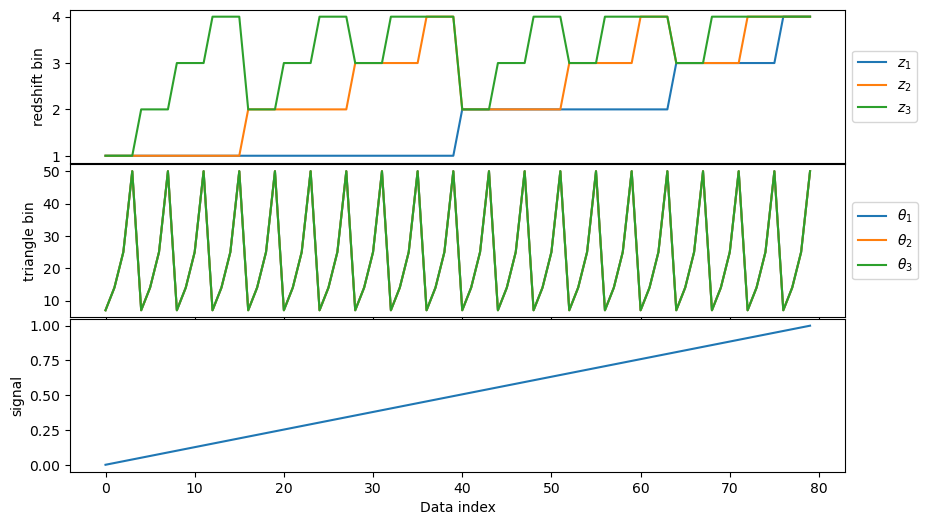

In [19]:
thpt = thpt.sort()
# Data ordering before sort
fig, axes = plt.subplots(3,1, figsize=(10, 6), sharex=True)
plt.subplots_adjust(hspace=0.01)
z1, z2, z3 = thpt.get_z_bin()
axes[0].plot(z1, label=r'$z_1$')
axes[0].plot(z2, label=r'$z_2$')
axes[0].plot(z3, label=r'$z_3$')
axes[0].set_ylabel(r'redshift bin')
axes[0].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
t1, t2, t3 = thpt.get_t_bin()
axes[1].plot(t1, label=r'$\theta_1$')
axes[1].plot(t2, label=r'$\theta_2$')
axes[1].plot(t3, label=r'$\theta_3$')
axes[1].set_ylabel(r'triangle bin')
axes[1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
s = thpt.get_signal()
axes[2].plot(s)
axes[2].set_ylabel(r'signal')
axes[2].set_xlabel('Data index')
plt.show()